Import necessary libraries

In [1]:
import cv2
import numpy as np
import urllib.request
import ssl
import matplotlib.pyplot as plt

Step 1: Load images

In [2]:
# Function to load image from a Google Drive shareable URL
def load_image_from_gdrive(gdrive_url):
    file_id = gdrive_url.split('/d/')[1].split('/')[0]
    direct_url = f"https://drive.google.com/uc?export=download&id={file_id}"
    context = ssl._create_unverified_context()
    resp = urllib.request.urlopen(direct_url, context=context)
    image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    return image

# URLs for scene 1 and scene 2
scene1_url = "https://drive.google.com/file/d/1l6GUpW_CuYxRPdTLt2uRnLB7V4EZaFSe/view?usp=sharing"
scene2_url = "https://drive.google.com/file/d/1mf8q4SB6ipeTO65VAJfIBWwtV4LZMjDo/view?usp=sharing"

# Load and resize images
scene1 = cv2.resize(load_image_from_gdrive(scene1_url), (600, 400))
scene2 = cv2.resize(load_image_from_gdrive(scene2_url), (600, 400))

# Convert to grayscale for feature extraction
gray1 = cv2.cvtColor(scene1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(scene2, cv2.COLOR_BGR2GRAY)

Step 3: SIFT Feature Matching

    SIFT (Scale-Invariant Feature Transform): Detects blobs invariant to scale and rotation

    Key formula:
        Difference of Gaussian (DoG) is used to approximate Laplacian of Gaussian

In [3]:
sift = cv2.SIFT_create()
kp1_sift, des1_sift = sift.detectAndCompute(gray1, None)
kp2_sift, des2_sift = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches_sift = bf.knnMatch(des1_sift, des2_sift, k=2)

# Apply Lowe's ratio test to select good matches
good_sift = []
for m, n in matches_sift:
    if m.distance < 0.75 * n.distance:
        good_sift.append([m])

img_sift = cv2.drawMatchesKnn(scene1, kp1_sift, scene2, kp2_sift, good_sift, None, flags=2)

Step 4: ORB Feature Matching

    ORB = Oriented FAST + Rotated BRIEF, good for real-time applications
        # FAST detects corners, BRIEF computes binary descriptors

In [4]:
orb = cv2.ORB_create()
kp1_orb, des1_orb = orb.detectAndCompute(gray1, None)
kp2_orb, des2_orb = orb.detectAndCompute(gray2, None)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(des1_orb, des2_orb)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)
img_orb = cv2.drawMatches(scene1, kp1_orb, scene2, kp2_orb, matches_orb[:50], None, flags=2)

Step 5: Visualization

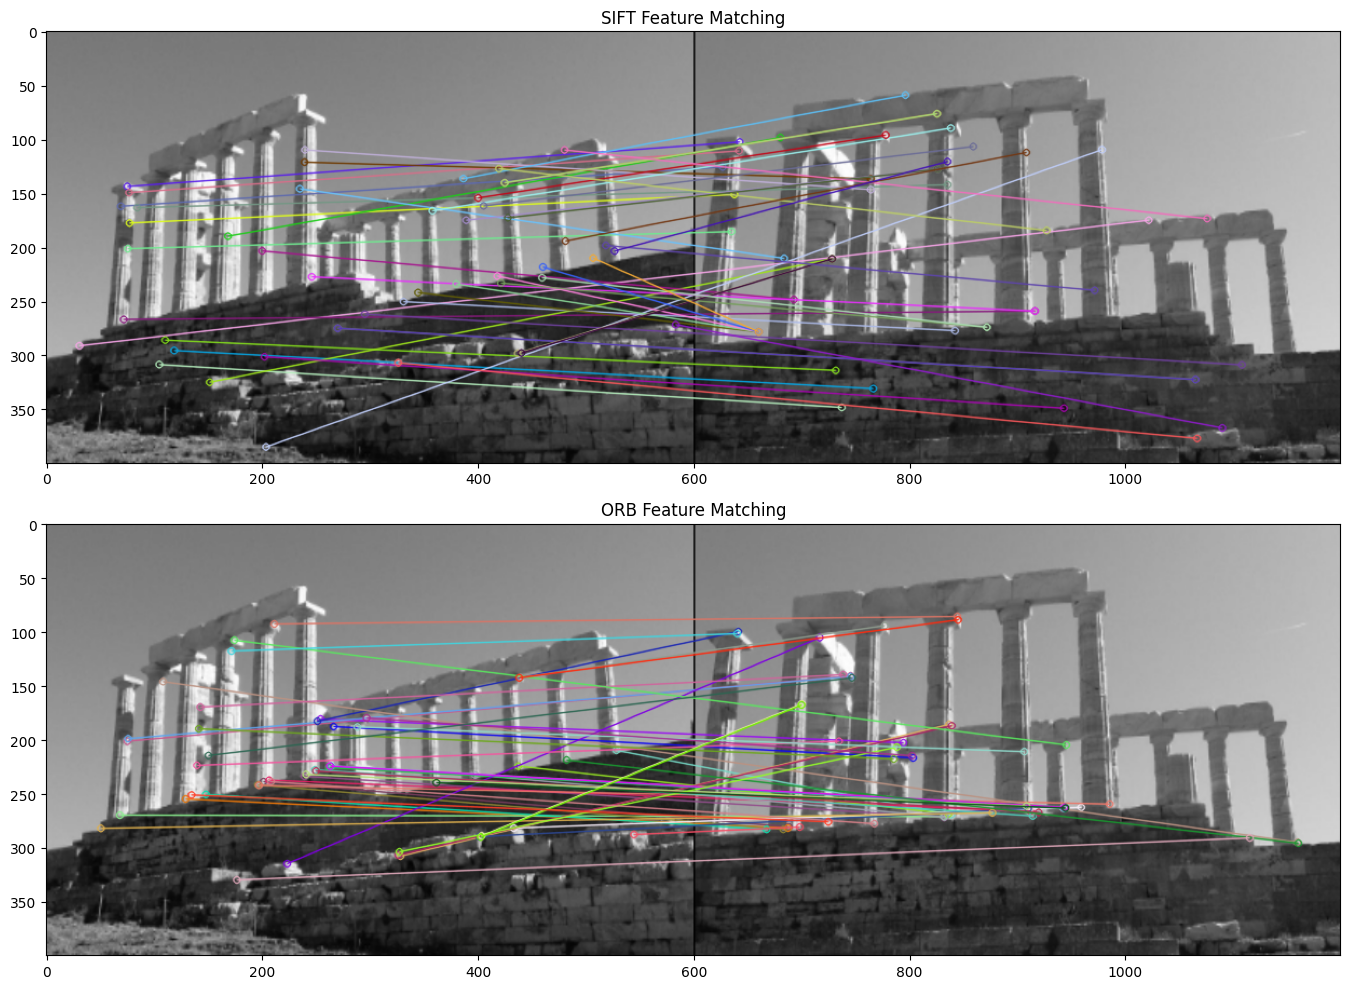

In [6]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Feature Matching")

plt.subplot(2, 1, 2)
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")

plt.tight_layout()
plt.show()